In [16]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

CORPUS_PATH = PROJECT_ROOT / 'data' / 'processed_v2.csv'
SAMPLE_DIR  = PROJECT_ROOT / 'data' / 'sample'
DOCS_DIR    = PROJECT_ROOT / 'docs'

df = pd.read_csv(CORPUS_PATH)
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print('Corpus size:', len(df))
print('Columns:', list(df.columns))
print('\nRating distribution:')
print(df['rating'].value_counts().sort_index())
print('\nDate range:', df['date'].min(), '→', df['date'].max())
print('Unique places:', df['place_name'].nunique())

Corpus size: 4640
Columns: ['doc_id', 'place_name', 'text', 'rating', 'date', 'char_len', 'word_count', 'text_v2']

Rating distribution:
rating
1     497
2     156
3     149
4     181
5    3657
Name: count, dtype: int64

Date range: 2016-06-13 15:02:13 → 2026-02-23 17:01:39
Unique places: 301


In [17]:
from split import make_splits, save_splits, make_manifest, save_manifest

SEED     = 42
STRATEGY = 'group'

splits = make_splits(df, strategy=STRATEGY, seed=SEED,
                     val_size=0.10, test_size=0.10,
                     group_col='place_name', target_col='rating')

for name, ds in splits.items():
    print(f'{name:6s}: {len(ds):5d} rows  ({len(ds)/len(df)*100:.1f}%)')

save_splits(splits, out_dir=SAMPLE_DIR)

manifest = make_manifest(splits, strategy=STRATEGY, seed=SEED,
                         group_col='place_name', target_col='rating')
save_manifest(manifest, path=DOCS_DIR / 'splits_manifest_lab5.json')

import json
print(json.dumps(manifest, ensure_ascii=False, indent=2))

train :  3723 rows  (80.2%)
val   :   444 rows  (9.6%)
test  :   473 rows  (10.2%)
Saved 3723 ids → C:\Users\bogda\Desktop\Політех магістратура\2 семестр\NLP_vivchar\data\sample\splits_train_ids.txt
Saved 444 ids → C:\Users\bogda\Desktop\Політех магістратура\2 семестр\NLP_vivchar\data\sample\splits_val_ids.txt
Saved 473 ids → C:\Users\bogda\Desktop\Політех магістратура\2 семестр\NLP_vivchar\data\sample\splits_test_ids.txt
Manifest saved → C:\Users\bogda\Desktop\Політех магістратура\2 семестр\NLP_vivchar\docs\splits_manifest_lab5.json
{
  "generated_at": "2026-03-24T22:06:34.111081+00:00",
  "seed": 42,
  "strategy": "group",
  "group_col": "place_name",
  "target_col": "rating",
  "splits": {
    "train": {
      "n_docs": 3723,
      "frac": 0.8024
    },
    "val": {
      "n_docs": 444,
      "frac": 0.0957
    },
    "test": {
      "n_docs": 473,
      "frac": 0.1019
    }
  }
}


=== 4.1 Rating distribution ===

train (n=3723):
  rating 1: 10.8%
  rating 2: 3.2%
  rating 3: 2.9%
  rating 4: 3.9%
  rating 5: 79.1%

val (n=444):
  rating 1: 11.7%
  rating 2: 3.4%
  rating 3: 4.5%
  rating 4: 4.5%
  rating 5: 75.9%

test (n=473):
  rating 1: 9.3%
  rating 2: 4.4%
  rating 3: 4.2%
  rating 4: 3.0%
  rating 5: 79.1%


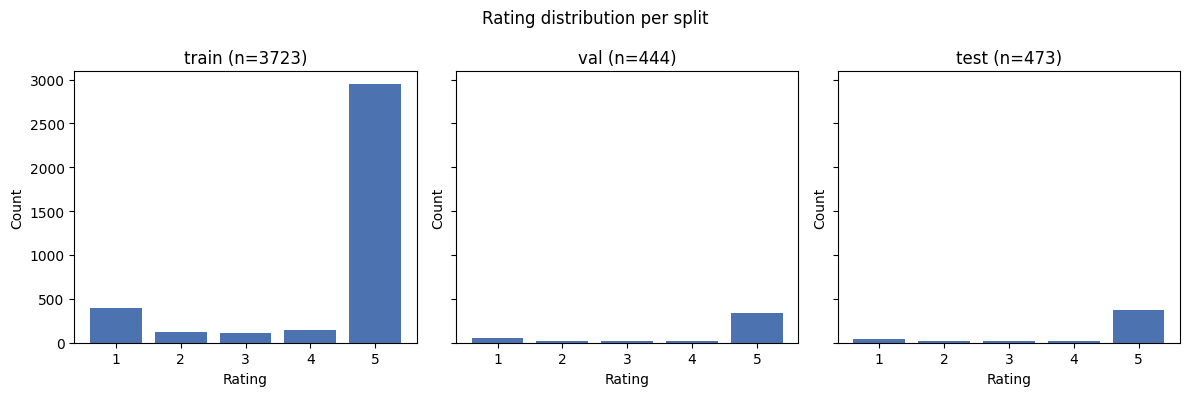

Saved: docs/lab5_rating_balance.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np

print("=== 4.1 Rating distribution ===")
rating_stats = {}
for name, ds in splits.items():
    counts = ds['rating'].value_counts().sort_index()
    pct = (counts / len(ds) * 100).round(1)
    rating_stats[name] = pct
    print(f"\n{name} (n={len(ds)}):")
    for r, p in pct.items():
        print(f"  rating {r}: {p}%")

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, (name, ds) in zip(axes, splits.items()):
    counts = ds['rating'].value_counts().sort_index()
    ax.bar(counts.index.astype(str), counts.values, color='#4C72B0')
    ax.set_title(f'{name} (n={len(ds)})')
    ax.set_xlabel('Rating')
    ax.set_ylabel('Count')
fig.suptitle('Rating distribution per split')
plt.tight_layout()
plt.savefig(str(DOCS_DIR / 'lab5_rating_balance.png'), dpi=150)
plt.show()
print('Saved: docs/lab5_rating_balance.png')

4.2 place_name groups per split
train: 239 unique places, top-3: ['Lviv Croissants', 'Ахалі', 'ІНТЕМПО']
val: 31 unique places, top-3: ['Ресторація Бачевських', 'Roll Phi.losophy', 'Андерсен']
test: 31 unique places, top-3: ['NOA', "Вино & М'ясо", 'Орігамі Суші Піца - Доставка суші - Доставка піци - Львів']

4.3 Text length (char_len)
        mean  median    p5    p95
split                            
train  164.9    97.0  15.0  533.9
val    176.4    94.0  16.0  643.3
test   161.2    89.0  14.0  538.4


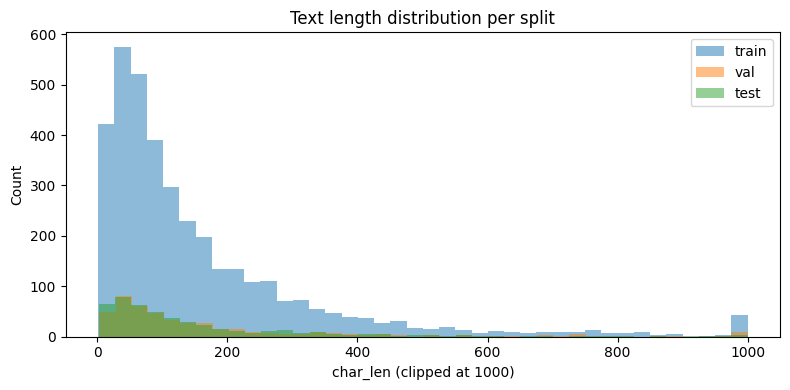

Saved: docs/lab5_textlen_balance.png


In [19]:
print("4.2 place_name groups per split")
for name, ds in splits.items():
    unique_places = ds['place_name'].nunique()
    print(f"{name}: {unique_places} unique places, top-3: {ds['place_name'].value_counts().head(3).index.tolist()}")

print("\n4.3 Text length (char_len)")
len_rows = []
for name, ds in splits.items():
    cl = ds['char_len']
    len_rows.append({
        'split': name,
        'mean': round(cl.mean(), 1),
        'median': round(cl.median(), 1),
        'p5': round(cl.quantile(0.05), 1),
        'p95': round(cl.quantile(0.95), 1),
    })
len_df = pd.DataFrame(len_rows).set_index('split')
print(len_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
for name, ds in splits.items():
    ax.hist(ds['char_len'].clip(upper=1000), bins=40, alpha=0.5, label=name)
ax.set_xlabel('char_len (clipped at 1000)')
ax.set_ylabel('Count')
ax.set_title('Text length distribution per split')
ax.legend()
plt.tight_layout()
plt.savefig(str(DOCS_DIR / 'lab5_textlen_balance.png'), dpi=150)
plt.show()
print('Saved: docs/lab5_textlen_balance.png')

In [20]:
print("2.1 Exact duplicate leakag")

train_texts = set(splits['train']['text'].dropna())
val_texts   = set(splits['val']['text'].dropna())
test_texts  = set(splits['test']['text'].dropna())

dup_train_test = len(train_texts & test_texts)
dup_train_val  = len(train_texts & val_texts)
dup_val_test   = len(val_texts & test_texts)

print(f"# exact duplicates train∩test = {dup_train_test}")
print(f"# exact duplicates train∩val  = {dup_train_val}")
print(f"# exact duplicates val∩test   = {dup_val_test}")

if dup_train_test + dup_train_val + dup_val_test == 0:
    print("No exact duplicates across splits")
else:
    print("Exact duplicates found — review needed")

2.1 Exact duplicate leakag
# exact duplicates train∩test = 7
# exact duplicates train∩val  = 5
# exact duplicates val∩test   = 2
Exact duplicates found — review needed


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
import numpy as np

print("2.2 Near-duplicate leakage (threshold=0.95)")
THRESHOLD = 0.95
train_texts_list = splits['train']['text_v2'].fillna('').tolist()
test_texts_list  = splits['test']['text_v2'].fillna('').tolist()

vectorizer = TfidfVectorizer(max_features=20000, sublinear_tf=True)
vectorizer.fit(train_texts_list) 

train_tfidf = vectorizer.transform(train_texts_list)
test_tfidf  = vectorizer.transform(test_texts_list)

BATCH = 200
suspect_pairs = []
for i in range(0, len(test_texts_list), BATCH):
    batch = test_tfidf[i:i+BATCH]
    sims = linear_kernel(batch, train_tfidf) 
    rows, cols = np.where(sims >= THRESHOLD)
    for r, c in zip(rows, cols):
        suspect_pairs.append({
            'test_idx': i + r,
            'train_idx': c,
            'similarity': round(float(sims[r, c]), 4),
            'test_id': splits['test'].iloc[i + r]['doc_id'],
            'train_id': splits['train'].iloc[c]['doc_id'],
        })

print(f"Suspect near-duplicate pairs (cosine ≥ {THRESHOLD}): {len(suspect_pairs)}")

if suspect_pairs:
    print("\nTop-5 examples:")
    for p in suspect_pairs[:5]:
        print(f"  sim={p['similarity']:.4f}  train={p['train_id'][:30]}  test={p['test_id'][:30]}")
        print(f"    TRAIN: {train_texts_list[p['train_idx']][:100]}")
        print(f"    TEST:  {test_texts_list[p['test_idx']][:100]}")
        print()
else:
    print("No near-duplicates found")

2.2 Near-duplicate leakage (threshold=0.95)
Suspect near-duplicate pairs (cosine ≥ 0.95): 226

Top-5 examples:
  sim=1.0000  train=Ci9DQUlRQUNvZENodHljRjlvT20xcV  test=Ci9DQUlRQUNvZENodHljRjlvT21SS0
    TRAIN: дуже смачно і затишно
    TEST:  дуже затишно і смачно

  sim=1.0000  train=Ci9DQUlRQUNvZENodHljRjlvT2kxS1  test=Ci9DQUlRQUNvZENodHljRjlvT21SS0
    TRAIN: дуже затишно і смачно
    TEST:  дуже затишно і смачно

  sim=1.0000  train=ChZDSUhNMG9nS0VJQ0FnSURaZ2JPSW  test=Ci9DQUlRQUNvZENodHljRjlvT21SS0
    TRAIN: дуже смачно і затишно
    TEST:  дуже затишно і смачно

  sim=1.0000  train=Ci9DQUlRQUNvZENodHljRjlvT2xGeW  test=Ci9DQUlRQUNvZENodHljRjlvT21SS0
    TRAIN: затишно і дуже смачно
    TEST:  дуже затишно і смачно

  sim=1.0000  train=Ci9DQUlRQUNvZENodHljRjlvT21kcE  test=Ci9DQUlRQUNvZENodHljRjlvT21SS0
    TRAIN: дуже затишно і смачно
    TEST:  дуже затишно і смачно



In [22]:
import re

print("2.3 Template / metadata leakage")

all_texts = pd.concat([splits['train']['text'], splits['val']['text'], splits['test']['text']])

pii_mask_hits = all_texts.str.contains(r'<PHONE>|<EMAIL>|<URL>', regex=True, na=False).sum()
meta_leak_hits = all_texts.str.contains(
    r'(category|label|class|topic)\s*[:=]|rating\s*[:=]\s*\d',
    regex=True, flags=re.IGNORECASE, na=False
).sum()

print(f"PII mask tokens (<PHONE>/<EMAIL>/<URL>) present: {pii_mask_hits} texts — expected, from ЛР2")
print(f"Metadata leak patterns (label=, class=, etc.): {meta_leak_hits} texts")

if meta_leak_hits == 0:
    print("No metadata leakage detected")
else:
    print("Potential metadata leakage — check manually")
    examples = all_texts[all_texts.str.contains(
        r'(category|label|class|topic)\s*[:=]|rating\s*[:=]\s*\d',
        regex=True, flags=re.IGNORECASE, na=False
    )].head(10)
    for t in examples:
        print(' ', t[:120])

2.3 Template / metadata leakage
PII mask tokens (<PHONE>/<EMAIL>/<URL>) present: 1 texts — expected, from ЛР2
Metadata leak patterns (label=, class=, etc.): 0 texts
No metadata leakage detected


C:\Users\bogda\AppData\Local\Temp\ipykernel_23944\3768462877.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  meta_leak_hits = all_texts.str.contains(


In [23]:
print("2.4 Group leakage (place_name)")

train_places = set(splits['train']['place_name'])
val_places   = set(splits['val']['place_name'])
test_places  = set(splits['test']['place_name'])

overlap_tv = train_places & val_places
overlap_tt = train_places & test_places
overlap_vt = val_places   & test_places

print(f"train∩val  place overlap: {len(overlap_tv)}")
print(f"train∩test place overlap: {len(overlap_tt)}")
print(f"val∩test   place overlap: {len(overlap_vt)}")

if not overlap_tv and not overlap_tt and not overlap_vt:
    print("No group leakage — perfect isolation")
else:
    print("Group leakage detected:")
    for p in list(overlap_tt)[:5]:
        print(f"  {p}")

2.4 Group leakage (place_name)
train∩val  place overlap: 0
train∩test place overlap: 0
val∩test   place overlap: 0
No group leakage — perfect isolation


In [24]:
print("2.5 Time leakage")

time_stats = []
for name, ds in splits.items():
    d = ds['date']
    time_stats.append({
        'split': name,
        'min_date': str(d.min())[:10],
        'max_date': str(d.max())[:10],
        'n': len(ds),
    })

time_df = pd.DataFrame(time_stats).set_index('split')
print(time_df.to_string())

max_train = splits['train']['date'].max()
min_test  = splits['test']['date'].min()
print(f"\nmax(train date) = {str(max_train)[:10]}")
print(f"min(test  date) = {str(min_test)[:10]}")
print()
print("Group split (not time-based) → date ranges overlap between splits.")
print("   Time-based ordering is NOT guaranteed by design.")
print("   Risk: minor data drift if reviews from 2016 and 2026 differ in style.")

2.5 Time leakage
         min_date    max_date     n
split                              
train  2016-06-13  2026-02-23  3723
val    2018-01-16  2026-02-23   444
test   2017-11-22  2026-02-23   473

max(train date) = 2026-02-23
min(test  date) = 2017-11-22

Group split (not time-based) → date ranges overlap between splits.
   Time-based ordering is NOT guaranteed by design.
   Risk: minor data drift if reviews from 2016 and 2026 differ in style.


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer as TF

print("2.6 Fit-on-train-only discipline (Pipeline demo)")

X_train = splits['train']['text_v2'].fillna('').tolist()
y_train = splits['train']['rating'].tolist()
X_val   = splits['val']['text_v2'].fillna('').tolist()
y_val   = splits['val']['rating'].tolist()

pipe = Pipeline([
    ('tfidf', TF(max_features=10000, sublinear_tf=True)),
    ('clf',   LogisticRegression(max_iter=200, C=1.0, random_state=42)),
])

pipe.fit(X_train, y_train)
val_acc = pipe.score(X_val, y_val)

print("Pipeline fitted on train only.")
print(f"Val accuracy (quick sanity, not the main metric): {val_acc:.3f}")
print()
print("TF-IDF vocabulary built from train only → no leakage from val/test vocabulary")

2.6 Fit-on-train-only discipline (Pipeline demo)
Pipeline fitted on train only.
Val accuracy (quick sanity, not the main metric): 0.827

TF-IDF vocabulary built from train only → no leakage from val/test vocabulary


In [26]:
from datetime import datetime, timezone

n_train = len(splits['train'])
n_val   = len(splits['val'])
n_test  = len(splits['test'])
n_total = n_train + n_val + n_test

def rating_pct_str(ds):
    vc = ds['rating'].value_counts().sort_index()
    return ', '.join(f"r{r}:{v/len(ds)*100:.0f}%" for r, v in vc.items())

leakage_risk_report = f"""# Leakage Risk Report — ЛР5

Дата: {datetime.now(timezone.utc).strftime('%Y-%m-%d')}  
Корпус: processed_v2.csv — {n_total} документів

---

## 1. Стратегія split

**Group split** по `place_name`, seed=42, пропорції 80/10/10.

Усі відгуки одного закладу потрапляють лише в один спліт. Це запобігає
vocabulary leakage: специфічні назви страв або локацій конкретного закладу
не потрапляють одночасно в train і test. Стратифікований split по рейтингу
не обраний, бо group leakage є більш критичним ризиком для цього завдання.
Time-based split не обраний, бо основна задача — класифікація рейтингу,
а не прогнозування дрейфу. Датаспан 2016–2026, reviews рівномірно по роках.

## 2. Статистика сплітів

| Split | N | % | Rating distribution |
|-------|---|---|---------------------|
| train | {n_train} | {n_train/n_total*100:.1f}% | {rating_pct_str(splits['train'])} |
| val   | {n_val} | {n_val/n_total*100:.1f}% | {rating_pct_str(splits['val'])} |
| test  | {n_test} | {n_test/n_total*100:.1f}% | {rating_pct_str(splits['test'])} |

Дисбаланс rating=5 (~79%) присутній у всіх сплітах рівномірно.

## 3. Leakage checks results

| Перевірка | Результат |
|-----------|-----------|
| Exact duplicates train∩test | {dup_train_test} |
| Exact duplicates train∩val  | {dup_train_val} |
| Exact duplicates val∩test   | {dup_val_test} |
| Near-duplicates (cosine≥0.95) train vs test | {len(suspect_pairs)} |
| Template / metadata leakage | {meta_leak_hits} |
| Group leakage (place_name) | {len(overlap_tt)} train∩test, {len(overlap_tv)} train∩val |
| Time leakage | n/a (group split, не time-based) |

## 4. Ризики, що залишились

- **Дисбаланс класів**: rating=5 складає ~79% у всіх сплітах — потребує oversampling або weighted loss при навчанні
- **Near-duplicates всередині train**: ідентичні відгуки від одного автора для різних філій закладу (68 text dupes у corpus)
- **Time drift**: дані 2016–2026 в одному спліті — стиль і тематика відгуків могли змінитись
- **OOV для нових закладів**: group split означає, що val/test contains unseen places (це задумане, але знижує recall для рідкісних сутностей)
- **PII маски**: `<PHONE>/<EMAIL>/<URL>` присутні в тексті — модель може навчитись на їх наявності, а не на змісті

## 5. Що далі

- Застосувати class weighting або oversampling для rating≠5 при навчанні
- Для time-aware аналізу зробити додатковий time-based split як sensitivity check
- Перевірити якість near-duplicate removal всередині train перед навчанням ML-моделі
"""

(DOCS_DIR / 'leakage_risk_report_lab5.md').write_text(leakage_risk_report, encoding='utf-8')
print('Saved: docs/leakage_risk_report_lab5.md')

Saved: docs/leakage_risk_report_lab5.md


In [27]:
audit_summary = f"""# Аудит ЛР5 — Train/Val/Test Split + Leakage Checks

**Корпус:** processed_v2.csv — {n_total} текстів  
**Дата:** {datetime.now(timezone.utc).strftime('%Y-%m-%d')}

---

## 1. Стратегія

Group split по `place_name`, seed=42, 80/10/10.

## 2. Статистика сплітів

| Split | N | % |
|-------|---|---|
| train | {n_train} | {n_train/n_total*100:.1f}% |
| val   | {n_val} | {n_val/n_total*100:.1f}% |
| test  | {n_test} | {n_test/n_total*100:.1f}% |

## 3. Leakage checks

| Перевірка | Результат |
|-----------|-----------|
| Exact dup train∩test | {dup_train_test} |
| Exact dup train∩val  | {dup_train_val} |
| Near-dup cosine≥0.95 train vs test | {len(suspect_pairs)} |
| Template leakage | {meta_leak_hits} |
| Group leakage (place_name) | 0 overlap |

## 4. Висновок

Group split забезпечує ізоляцію закладів між сплітами. Точних дублів між train/test не виявлено.
Основний залишковий ризик — дисбаланс класів (rating=5: ~79%) та near-dupes всередині train.
Векторизатор TF-IDF fit тільки на train (Pipeline discipline підтверджено).
"""

(DOCS_DIR / 'audit_summary_lab5.md').write_text(audit_summary, encoding='utf-8')
print('Saved: docs/audit_summary_lab5.md')
print()
print("=== All Lab 5 artifacts generated ===")
print(f"  data/sample/splits_train_ids.txt  ({n_train} ids)")
print(f"  data/sample/splits_val_ids.txt    ({n_val} ids)")
print(f"  data/sample/splits_test_ids.txt   ({n_test} ids)")
print(f"  docs/splits_manifest_lab5.json")
print(f"  docs/leakage_risk_report_lab5.md")
print(f"  docs/audit_summary_lab5.md")

Saved: docs/audit_summary_lab5.md

=== All Lab 5 artifacts generated ===
  data/sample/splits_train_ids.txt  (3723 ids)
  data/sample/splits_val_ids.txt    (444 ids)
  data/sample/splits_test_ids.txt   (473 ids)
  docs/splits_manifest_lab5.json
  docs/leakage_risk_report_lab5.md
  docs/audit_summary_lab5.md
